In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
import os

def video_ozeti(base_path):
    print("📂 Video Klasör Analizi Başlatıldı...\n")
    for cls in ['original_sequences', 'manipulated_sequences']: # Senin klasör isimlerin neyse onları yaz
        cls_full_path = os.path.join(base_path, cls)

        if os.path.exists(cls_full_path):
            # Alt klasörleri kontrol et (Deepfakes, Face2Face vb. olabilir)
            subfolders = [f for f in os.listdir(cls_full_path) if os.path.isdir(os.path.join(cls_full_path, f))]

            if not subfolders: # Eğer direkt videolar varsa
                videos = [v for v in os.listdir(cls_full_path) if v.endswith(('.mp4', '.avi'))]
                print(f"🎬 {cls}: {len(videos)} video bulundu.")
                if videos: print(f"   📝 Örnek dosya: {videos[0]}")
            else:
                for sub in subfolders:
                    sub_path = os.path.join(cls_full_path, sub)
                    videos = [v for v in os.listdir(sub_path) if v.endswith(('.mp4', '.avi'))]
                    print(f"📁 {cls} -> {sub}: {len(videos)} video.")
                    if videos: print(f"   📝 Örnek dosya: {videos[0]}")
        else:
            print(f"❌ HATA: {cls_full_path} yolu bulunamadı!")
        print("-" * 30)

# Kendi Drive yolunu buraya yaz:
video_yolu = '/content/drive/MyDrive/FaceForensics_Data/' # Burayı videoların olduğu ana klasör yap
video_ozeti(video_yolu)

📂 Video Klasör Analizi Başlatıldı...

📁 original_sequences -> youtube: 0 video.
📁 original_sequences -> actors: 0 video.
------------------------------
📁 manipulated_sequences -> Deepfakes: 0 video.
📁 manipulated_sequences -> DeepFakeDetection: 0 video.
------------------------------


In [ ]:
import os

# Ana yolu bir kontrol edelim
ana_yol = '/content/drive/MyDrive/FaceForensics_Data/' # Burayı kendi ana klasörün yap

print(f"📁 {ana_yol} içindeki her şey:")
for item in os.listdir(ana_yol):
    print(f"  - {item}")

📁 /content/drive/MyDrive/FaceForensics_Data/ içindeki her şey:
  - dataset_frames
  - original_sequences
  - manipulated_sequences
  - deepfake_detector_final.h5
  - egitim_performans_grafikleri.png
  - deepfake_detector_optuna_final.h5
  - deepfake_detector_optuna_final.keras
  - deepfake_detector_FINAL_TAMAMLANDI.h5
  - deepfake_detector_FINAL_MODEL.h5
  - deepfake_detector_FINAL_V2.h5
  - grafik_v2.png
  - best_model_checkpoint.h5
  - deepfake_detector_FINETUNED.h5
  - grafik_finetuned.png
  - best_model_finetuned.h5
  - grafik_final.png
  - roc_egrisi.png
  - hoca_stili_dataset
  - fixed_labels_model.h5
  - best_model_final.h5
  - best_model_v3.h5
  - final_best_model.h5
  - best_model_v4_final.h5
  - deepfake_detector_FINAL_V4.h5
  - crop_dataset
  - best_deepfake_model.h5
  - training_grafik.png
  - hoca_istegi_final_model.h5
  - hoca_patience10_model.h5


In [ ]:
import os

# TAM YOLLAR (Görüntüdeki hiyerarşiye göre)
real_video_path = '/content/drive/MyDrive/FaceForensics_Data/original_sequences/youtube/c23/videos'
fake_video_path = '/content/drive/MyDrive/FaceForensics_Data/manipulated_sequences/Deepfakes/c23/videos'

def say_ve_listele(yol, etiket):
    if os.path.exists(yol):
        dosyalar = [f for f in os.listdir(yol) if f.endswith(('.mp4', '.avi'))]
        print(f"🎬 {etiket} Klasöründe {len(dosyalar)} video var.")
        if dosyalar:
            print(f"   📝 İlk 3 örnek: {dosyalar[:3]}")
    else:
        print(f"❌ HATA: {yol} bulunamadı!")

say_ve_listele(real_video_path, "GERÇEK (Real)")
say_ve_listele(fake_video_path, "SAHTE (Fake)")

🎬 GERÇEK (Real) Klasöründe 1000 video var.
   📝 İlk 3 örnek: ['585.mp4', '599.mp4', '469.mp4']
🎬 SAHTE (Fake) Klasöründe 1000 video var.
   📝 İlk 3 örnek: ['141_161.mp4', '585_599.mp4', '599_585.mp4']


In [ ]:
import os

def dataset_frames_analiz(path):
    # Sınıf klasörlerini kontrol et
    classes = ['fake', 'real']

    for cls in classes:
        cls_path = os.path.join(path, cls)
        if not os.path.exists(cls_path):
            print(f"❌ {cls} klasörü bulunamadı!")
            continue

        # Klasördeki tüm resim dosyalarını al
        all_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Dosya isimlerinden video adlarını ayıkla
        # Örn: '585.mp4_100.jpg' -> '585.mp4'
        video_ids = set()
        for f in all_files:
            # Dosya isminde videonun adını yakalamaya çalışıyoruz
            # Eğer isimlendirme 'v_id_frame.jpg' şeklindeyse split ile ayırıyoruz
            parts = f.split('_')
            if len(parts) > 1:
                v_id = parts[0]
                video_ids.add(v_id)

        print(f"📊 {cls.upper()} Klasörü Analizi:")
        print(f"   - Toplam Resim Sayısı: {len(all_files)}")
        print(f"   - Benzersiz Video Sayısı: {len(video_ids)}")
        if video_ids:
            sample_ids = list(video_ids)[:5]
            print(f"   - Örnek Video ID'leri: {sample_ids}")
        print("-" * 30)

# Yolu buraya yaz
analiz_yolu = '/content/drive/MyDrive/FaceForensics_Data/dataset_frames'
dataset_frames_analiz(analiz_yolu)

📊 FAKE Klasörü Analizi:
   - Toplam Resim Sayısı: 5787
   - Benzersiz Video Sayısı: 339
   - Örnek Video ID'leri: ['731', '388', '263', '863', '583']
------------------------------
📊 REAL Klasörü Analizi:
   - Toplam Resim Sayısı: 5192
   - Benzersiz Video Sayısı: 151
   - Örnek Video ID'leri: ['456.mp4', '210.mp4', '942.mp4', '261.mp4', '878.mp4']
------------------------------


In [ ]:
import os
import random
import shutil

# 1. KAYNAK YOLLAR
real_src = '/content/drive/MyDrive/FaceForensics_Data/original_sequences/youtube/c23/videos'
fake_src = '/content/drive/MyDrive/FaceForensics_Data/manipulated_sequences/Deepfakes/c23/videos'
dest_root = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Video_Dataset_V5'

def video_bazli_ayir(r_limit=150, f_limit=340):
    # Temizlik
    if os.path.exists(dest_root): shutil.rmtree(dest_root)

    # Dosya listelerini al
    r_vids = sorted([v for v in os.listdir(real_src) if v.endswith('.mp4')])[:r_limit]
    f_vids = sorted([v for v in os.listdir(fake_src) if v.endswith('.mp4')])[:f_limit]

    random.seed(42)
    random.shuffle(r_vids)
    random.shuffle(f_vids)

    # İşlem döngüsü (Real ve Fake için)
    for label, v_list, src_path in [('real', r_vids, real_src), ('fake', f_vids, fake_src)]:
        n = len(v_list)
        # %80 Train, %10 Val, %10 Test
        train_end = int(n * 0.8)
        val_end = int(n * 0.9)

        splits = {
            'train': v_list[:train_end],
            'val': v_list[train_end:val_end],
            'test': v_list[val_end:]
        }

        for split_name, v_sub_list in splits.items():
            out_dir = os.path.join(dest_root, split_name, label)
            os.makedirs(out_dir, exist_ok=True)
            print(f"🚚 {split_name}/{label}: {len(v_sub_list)} video kopyalanıyor...")

            for v_name in v_sub_list:
                shutil.copy(os.path.join(src_path, v_name), os.path.join(out_dir, v_name))

# ÇALIŞTIR
video_bazli_ayir()
print("\n✅ Video Ayırma İşlemi Tamam! Klasörler videolardan oluşuyor.")

🚚 train/real: 120 video kopyalanıyor...
🚚 val/real: 15 video kopyalanıyor...
🚚 test/real: 15 video kopyalanıyor...
🚚 train/fake: 272 video kopyalanıyor...
🚚 val/fake: 34 video kopyalanıyor...
🚚 test/fake: 34 video kopyalanıyor...

✅ Video Ayırma İşlemi Tamam! Klasörler videolardan oluşuyor.


In [ ]:
import cv2
import os

# YOLLAR (Video klasörlerini kaynak alıyoruz)
video_root = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Video_Dataset_V5'
image_root = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dataset_V6'

def kareleri_tek_tek_ayikla(v_yolu, k_yolu, etiket, v_id):
    cap = cv2.VideoCapture(v_yolu)
    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # İŞTE SENİN ŞARTIN: Her 30 karede bir kaydet
        if frame_count % 30 == 0:
            # Örn: REAL_585_frame30.jpg
            dosya_adi = f"{etiket.upper()}_{v_id}_frame{frame_count}.jpg"
            cv2.imwrite(os.path.join(k_yolu, dosya_adi), frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    return saved_count

# KLASÖRLERİ GEZ VE İŞLE
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        source_dir = os.path.join(video_root, split, label)
        target_dir = os.path.join(image_root, split, label)
        os.makedirs(target_dir, exist_ok=True)

        videos = [v for v in os.listdir(source_dir) if v.endswith('.mp4')]
        print(f"🚀 {split}/{label} işleniyor... ({len(videos)} video)")

        for v_name in videos:
            v_id = v_name.split('.')[0]
            kareleri_tek_tek_ayikla(
                os.path.join(source_dir, v_name),
                target_dir,
                label,
                v_id
            )

print("\n✅ V6 Görüntü Seti Hazır! 'if frame_count % 30 == 0' kuralıyla kareler alındı.")

🚀 train/real işleniyor... (120 video)
🚀 train/fake işleniyor... (272 video)
🚀 val/real işleniyor... (15 video)
🚀 val/fake işleniyor... (34 video)
🚀 test/real işleniyor... (15 video)
🚀 test/fake işleniyor... (34 video)

✅ V6 Görüntü Seti Hazır! 'if frame_count % 30 == 0' kuralıyla kareler alındı.


In [ ]:
import os

def dataset_ozeti(root_path):
    print(f"📁 Veri Seti Analizi: {root_path}\n")
    print(f"{'Klasör':<15} | {'REAL':<10} | {'FAKE':<10} | {'TOPLAM':<10}")
    print("-" * 50)

    genel_toplam = 0
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(root_path, split)
        if not os.path.exists(split_path): continue

        real_count = len(os.listdir(os.path.join(split_path, 'real')))
        fake_count = len(os.listdir(os.path.join(split_path, 'fake')))
        split_toplam = real_count + fake_count
        genel_toplam += split_toplam

        print(f"{split.capitalize():<15} | {real_count:<10} | {fake_count:<10} | {split_toplam:<10}")

    print("-" * 50)
    print(f"{'GENEL TOPLAM':<30} | {genel_toplam:<10}")

# Analiz edilecek yeni klasör yolun:
v6_yolu = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dataset_V6'
dataset_ozeti(v6_yolu)

📁 Veri Seti Analizi: /content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dataset_V6

Klasör          | REAL       | FAKE       | TOPLAM    
--------------------------------------------------
Train           | 2097       | 4978       | 7075      
Val             | 269        | 572        | 841       
Test            | 226        | 570        | 796       
--------------------------------------------------
GENEL TOPLAM                   | 8712      


In [ ]:
import os
import shutil
import random
from collections import defaultdict

def hoca_stili_guvenli_ayir(source, destination):
    if os.path.exists(destination):
        print("🗑️ Eski dataset siliniyor...")
        shutil.rmtree(destination)

    # 1. Adım: Tüm benzersiz ana video ID'lerini topla (Örn: 004_982 -> 004)
    # FaceForensics'te ilk numara genelde ana video ID'sidir.
    all_base_ids = set()
    for cls in ['fake', 'real']:
        path = os.path.join(source, cls)
        for f in os.listdir(path):
            if '.mp4' in f:
                base_id = f.split('_')[0] # "004_982" -> "004"
                all_base_ids.add(base_id)

    video_list = list(all_base_ids)
    random.seed(42)
    random.shuffle(video_list)

    # 2. Adım: Ana ID'leri gruplara böl (%80, %10, %10)
    n = len(video_list)
    train_ids = set(video_list[:int(n * 0.8)])
    val_ids = set(video_list[int(n * 0.8):int(n * 0.9)])
    test_ids = set(video_list[int(n * 0.9):])

    # 3. Adım: Dosyaları ait oldukları ID grubuna göre kopyala
    for cls in ['fake', 'real']:
        cls_path = os.path.join(source, cls)
        for f in os.listdir(cls_path):
            if '.mp4' not in f: continue

            base_id = f.split('_')[0]

            if base_id in train_ids: split = 'train'
            elif base_id in val_ids: split = 'val'
            else: split = 'test'

            dest_dir = os.path.join(destination, split, cls)
            os.makedirs(dest_dir, exist_ok=True)
            shutil.copy(os.path.join(cls_path, f), os.path.join(dest_dir, f))

    print("✅ Güvenli ayırma tamamlandı! Artık bir video asla iki farklı grupta olamaz.")

# Çalıştır
kaynak = '/content/drive/MyDrive/FaceForensics_Data/dataset_frames'
hedef = '/content/drive/MyDrive/FaceForensics_Data/hoca_stili_dataset_V2'
hoca_stili_guvenli_ayir(kaynak, hedef)

✅ Güvenli ayırma tamamlandı! Artık bir video asla iki farklı grupta olamaz.


In [ ]:
import tensorflow as tf
import os

# Yeni oluşturduğun hedef yolu buraya yazıyoruz
base_path = '/content/drive/MyDrive/FaceForensics_Data/hoca_stili_dataset_V2'

print("🔍 Veri seti kontrol ediliyor...\n")

def check_split(split_name):
    path = os.path.join(base_path, split_name)
    if not os.path.exists(path):
        print(f"❌ {split_name} klasörü bulunamadı!")
        return

    # TensorFlow'un klasörleri görüp görmediğini test edelim
    try:
        ds = tf.keras.utils.image_dataset_from_directory(
            path,
            image_size=(224, 224),
            batch_size=32
        )
        print(f"✅ {split_name.upper()} seti tamam: {len(ds.file_paths)} dosya ve {len(ds.class_names)} sınıf bulundu.")
        print(f"   Sınıflar: {ds.class_names}")
    except Exception as e:
        print(f"❌ {split_name} okunurken hata oluştu: {e}")

# Üç grubu da kontrol et
check_split('train')
check_split('val')
check_split('test')

print("\n🚀 Eğer yukarıda '2 classes' ve yüksek dosya sayıları görüyorsan, yarın eğitime hazırız!")

🔍 Veri seti kontrol ediliyor...

Found 9179 files belonging to 2 classes.
✅ TRAIN seti tamam: 9179 dosya ve 2 sınıf bulundu.
   Sınıflar: ['fake', 'real']
Found 897 files belonging to 2 classes.
✅ VAL seti tamam: 897 dosya ve 2 sınıf bulundu.
   Sınıflar: ['fake', 'real']
Found 902 files belonging to 2 classes.
✅ TEST seti tamam: 902 dosya ve 2 sınıf bulundu.
   Sınıflar: ['fake', 'real']

🚀 Eğer yukarıda '2 classes' ve yüksek dosya sayıları görüyorsan, yarın eğitime hazırız!


In [ ]:
import os
import random
import shutil

# KAYNAK YOLLAR
real_src = '/content/drive/MyDrive/FaceForensics_Data/original_sequences/youtube/c23/videos'
fake_src = '/content/drive/MyDrive/FaceForensics_Data/manipulated_sequences/Deepfakes/c23/videos'
video_dest = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Video_Dengeli_V7'

def dengeli_video_ayir(limit=200):
    if os.path.exists(video_dest): shutil.rmtree(video_dest)

    # Her iki taraftan da tam olarak 'limit' kadar video al
    r_vids = sorted([v for v in os.listdir(real_src) if v.endswith('.mp4')])[:limit]
    f_vids = sorted([v for v in os.listdir(fake_src) if v.endswith('.mp4')])[:limit]

    random.seed(42)
    random.shuffle(r_vids)
    random.shuffle(f_vids)

    for label, v_list, src in [('real', r_vids, real_src), ('fake', f_vids, fake_src)]:
        n = len(v_list)
        train_end = int(n * 0.8) # 160 video
        val_end = int(n * 0.9)   # 20 video
        # Geriye kalan 20 video Test olacak

        splits = {'train': v_list[:train_end], 'val': v_list[train_end:val_end], 'test': v_list[val_end:]}

        for split_name, v_sub in splits.items():
            out_dir = os.path.join(video_dest, split_name, label)
            os.makedirs(out_dir, exist_ok=True)
            for v_name in v_sub:
                shutil.copy(os.path.join(src, v_name), os.path.join(out_dir, v_name))
    print(f"✅ 200 Real ve 200 Fake video başarıyla {video_dest} klasörüne kopyalandı!")

dengeli_video_ayir(limit=200)

✅ 200 Real ve 200 Fake video başarıyla /content/drive/MyDrive/FaceForensics_Data/Hoca_Video_Dengeli_V7 klasörüne kopyalandı!


In [ ]:
import cv2
import os

# YOLLAR (Ayırdığın 200-200 videoları buradan okuyacak)
video_root = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Video_Dengeli_V7'
image_root = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7'

def kareleri_tek_tek_ayikla(v_yolu, k_yolu, etiket, v_id):
    cap = cv2.VideoCapture(v_yolu)
    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # SENİN ŞARTIN: Her 30 karede bir kaydet
        if frame_count % 30 == 0:
            # Örn: REAL_585_frame30.jpg
            dosya_adi = f"{etiket.upper()}_{v_id}_frame{frame_count}.jpg"
            cv2.imwrite(os.path.join(k_yolu, dosya_adi), frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    return saved_count

# KLASÖRLERİ GEZ VE İŞLE
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        source_dir = os.path.join(video_root, split, label)
        target_dir = os.path.join(image_root, split, label)

        if not os.path.exists(source_dir):
            print(f"⚠️ Klasör bulunamadı: {source_dir}")
            continue

        os.makedirs(target_dir, exist_ok=True)

        videos = [v for v in os.listdir(source_dir) if v.endswith('.mp4')]
        print(f"🚀 {split}/{label} işleniyor... ({len(videos)} video)")

        for v_name in videos:
            v_id = v_name.split('.')[0]
            kareleri_tek_tek_ayikla(
                os.path.join(source_dir, v_name),
                target_dir,
                label,
                v_id
            )

print("\n✅ V7 Dengeli Görüntü Seti Hazır! Senin 'mod 30' kuralınla her şey jilet gibi ayrıldı.")

🚀 train/real işleniyor... (160 video)
🚀 train/fake işleniyor... (160 video)
🚀 val/real işleniyor... (20 video)
🚀 val/fake işleniyor... (20 video)
🚀 test/real işleniyor... (20 video)
🚀 test/fake işleniyor... (20 video)

✅ V7 Dengeli Görüntü Seti Hazır! Senin 'mod 30' kuralınla her şey jilet gibi ayrıldı.


In [ ]:
import os

def dataset_ozeti(root_path):
    # Klasör var mı kontrolü
    if not os.path.exists(root_path):
        print(f"❌ Hata: '{root_path}' yolu bulunamadı!")
        print("Lütfen klasör isminin 'Hoca_Image_Dengeli_V7' olduğundan emin ol.")
        return

    print(f"📊 V7 DENGELİ VERİ SETİ ANALİZİ: {root_path}\n")
    print(f"{'Klasör':<15} | {'REAL':<10} | {'FAKE':<10} | {'TOPLAM':<10}")
    print("-" * 52)

    genel_toplam = 0
    # train, val, test klasörlerini sırayla gez
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(root_path, split)

        if not os.path.exists(split_path):
            print(f"{split.capitalize():<15} | Klasör Yok  | Klasör Yok  | -")
            continue

        # Alt klasör yolları
        real_dir = os.path.join(split_path, 'real')
        fake_dir = os.path.join(split_path, 'fake')

        # Sadece resim dosyalarını (.jpg, .png, .jpeg) say
        def dosya_say(yol):
            if not os.path.exists(yol): return 0
            return len([f for f in os.listdir(yol) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        real_count = dosya_say(real_dir)
        fake_count = dosya_say(fake_dir)

        split_toplam = real_count + fake_count
        genel_toplam += split_toplam

        print(f"{split.capitalize():<15} | {real_count:<10} | {fake_count:<10} | {split_toplam:<10}")

    print("-" * 52)
    print(f"{'GENEL TOPLAM':<31} | {genel_toplam:<10}")

# ANALİZ EDİLECEK YENİ YOL:
v7_yolu = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7'
dataset_ozeti(v7_yolu)

📊 V7 DENGELİ VERİ SETİ ANALİZİ: /content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7

Klasör          | REAL       | FAKE       | TOPLAM    
----------------------------------------------------
Train           | 2822       | 2857       | 5679      
Val             | 425        | 326        | 751       
Test            | 303        | 367        | 670       
----------------------------------------------------
GENEL TOPLAM                    | 7100      


In [ ]:
import os

# 1. Dataset ana yolun (En son klasör ismine göre güncellendi)
dataset_yolu = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7'

def video_id_ayikla(klasor):
    """
    Dosya isminden video ID'sini (örn: 016_209) ayıklar ve benzersiz set olarak döner.
    """
    video_ids = set()
    if not os.path.exists(klasor):
        return video_ids

    for label in ['real', 'fake']:
        yol = os.path.join(klasor, label)
        if os.path.exists(yol):
            dosyalar = os.listdir(yol)
            for f in dosyalar:
                # Sadece resim dosyalarına bak ve gizli dosyaları (._) atla
                if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('.'):
                    # Format: FAKE_016_209_frame0.jpg
                    parcalar = f.split('_')
                    if len(parcalar) >= 3:
                        # '016' + '_' + '209' kısmını birleştiriyoruz
                        video_id = parcalar[1] + "_" + parcalar[2]
                        video_ids.add(video_id)
    return video_ids

print("📊 Video bazlı ayrım (Data Leakage) kontrolü başlatıldı...\n")

# Her klasördeki benzersiz videoları bul
train_ids = video_id_ayikla(os.path.join(dataset_yolu, 'train'))
val_ids = video_id_ayikla(os.path.join(dataset_yolu, 'val'))
test_ids = video_id_ayikla(os.path.join(dataset_yolu, 'test'))

# Çakışma Kontrolü (Kümelerin kesişimini al)
train_val_cakisma = train_ids.intersection(val_ids)
train_test_cakisma = train_ids.intersection(test_ids)
val_test_cakisma = val_ids.intersection(test_ids)

print("-" * 50)
print(f"📺 Benzersiz Video İstatistikleri:")
print(f"  🔹 Train içindeki video sayısı: {len(train_ids)}")
print(f"  🔹 Val içindeki video sayısı:   {len(val_ids)}")
print(f"  🔹 Test içindeki video sayısı:  {len(test_ids)}")
print("-" * 50)

# Sonuç Raporu
hata_var_mi = False

if train_val_cakisma:
    print(f"❌ HATA: {len(train_val_cakisma)} video hem Train hem Val içinde!")
    print(f"   👉 Örnek çakışanlar: {list(train_val_cakisma)[:3]}")
    hata_var_mi = True

if train_test_cakisma:
    print(f"❌ HATA: {len(train_test_cakisma)} video hem Train hem Test içinde!")
    print(f"   👉 Örnek çakışanlar: {list(train_test_cakisma)[:3]}")
    hata_var_mi = True

if val_test_cakisma:
    print(f"❌ HATA: {len(val_test_cakisma)} video hem Val hem Test içinde!")
    print(f"   👉 Örnek çakışanlar: {list(val_test_cakisma)[:3]}")
    hata_var_mi = True

if not hata_var_mi:
    print("\n✅ MÜKEMMEL: Hiçbir video çakışması bulunamadı.")
    print("🚀 Hocanın 'Video-level split' kuralına %100 uyulmuş. Eğitime başlayabilirsin!")
else:
    print("\n⚠️ DİKKAT: Yukarıdaki çakışmaları çözmeden eğitime başlarsan başarı 'sahte' çıkacaktır.")

📊 Video bazlı ayrım (Data Leakage) kontrolü başlatıldı...

--------------------------------------------------
📺 Benzersiz Video İstatistikleri:
  🔹 Train içindeki video sayısı: 2982
  🔹 Val içindeki video sayısı:   445
  🔹 Test içindeki video sayısı:  323
--------------------------------------------------

✅ MÜKEMMEL: Hiçbir video çakışması bulunamadı.
🚀 Hocanın 'Video-level split' kuralına %100 uyulmuş. Eğitime başlayabilirsin!


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# ===== 1. DATASET =====
train_dir = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/train'
val_dir   = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/val'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

# ===== 2. AUGMENTATION (HAFİF) =====
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y)) \
                   .cache() \
                   .shuffle(1000) \
                   .prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

# ===== 3. BASE MODEL =====
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# 🔥 DENGE AYARI
base_model.trainable = False
for layer in base_model.layers[-80:]:
    layer.trainable = True

# ===== 4. MODEL =====
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# ===== 5. COMPILE =====
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),  # 🔥 önemli
    loss='binary_crossentropy',                    # 🔥 smoothing kaldırıldı
    metrics=['accuracy']
)

# ===== 6. CALLBACKS =====
callback_list = [

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/FaceForensics_Data/best_model_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ===== 7. TRAIN =====
print("\n🚀 DENGELİ MODEL BAŞLIYOR (underfitting çözüldü)")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callback_list
)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.

🚀 DENGELİ MODEL BAŞLIYOR (underfitting çözüldü)
Epoch 1/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4955 - loss: 0.8940
Epoch 1: val_accuracy improved from None to 0.56591, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 909s 4s/step - accuracy: 0.5027 - loss: 0.8567 - val_accuracy: 0.5659 - val_loss: 0.6845 - learning_rate: 1.0000e-04
Epoch 2/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5076 - loss: 0.7821
Epoch 2: val_accuracy did not improve from 0.56591
178/178 ━━━━━━━━━━━━━━━━━━━━ 761s 4s/step - accuracy: 0.5057 - loss: 0.7721 - val_accuracy: 0.4341 - val_loss: 0.7435 - learning_rate: 1.0000e-04
Epoch 3/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5045 - loss: 0.7434
Epoch 3: ReduceLROnPlateau reducing le

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# ===== 1. DATASET =====
# Klasör yollarını senin V7 yapına göre sabitledim
train_dir = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/train'
val_dir   = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/val'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=16, # 32 RAM'i zorlayabilir, 16 daha stabil
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=16,
    label_mode='binary',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

# ===== 2. AUGMENTATION & OPTİMİZASYON =====
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1) # Biraz zoom eklemek deepfake için iyidir
])

# Kodun akışını bozan noktaları düzelttim
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# ===== 3. BASE MODEL =====
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# 🔥 İNCE AYAR (Fine-Tuning)
base_model.trainable = True
for layer in base_model.layers[:-60]: # Son 60 katman idealdir
    layer.trainable = False

# ===== 4. MODEL KURULUMU =====
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    # EfficientNetB0 içinde kendi rescaling katmanı olduğu için manuel eklemiyoruz
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'), # Kapasiteyi artırdık
    layers.Dropout(0.5), # Ezberlemeye karşı koruma
    layers.Dense(1, activation='sigmoid')
])

# ===== 5. COMPILE =====
model.compile(
    optimizer=optimizers.Adam(learning_rate=2e-5), # Hızı daha stabil bir yere çektim
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== 6. CALLBACKS =====
callback_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8, # Daha fazla şans veriyoruz
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/FaceForensics_Data/best_model_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ===== 7. TRAIN =====
print("\n🚀 GPU Kontrolü ve Eğitim Başlıyor...")
print("GPU Mevcut mu: ", tf.config.list_physical_devices('GPU'))

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callback_list
)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🚀 GPU Kontrolü ve Eğitim Başlıyor...
GPU Mevcut mu:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/30
354/355 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4955 - loss: 0.9870
Epoch 1: val_accuracy improved from None to 0.36485, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 1658s 981ms/step - accuracy: 0.5198 - loss: 0.9232 - val_accuracy: 0.3648 - val_loss: 0.9562 - learning_rate: 2.0000e-05
Epoch 2/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5838 - loss: 0.7708
Epoch 2: val_accuracy did not improve from 0.36485
355/355 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.5982 - loss: 0.7497 - val_accuracy: 0.2743 - val_loss: 1.1802 - learning_rate: 2.

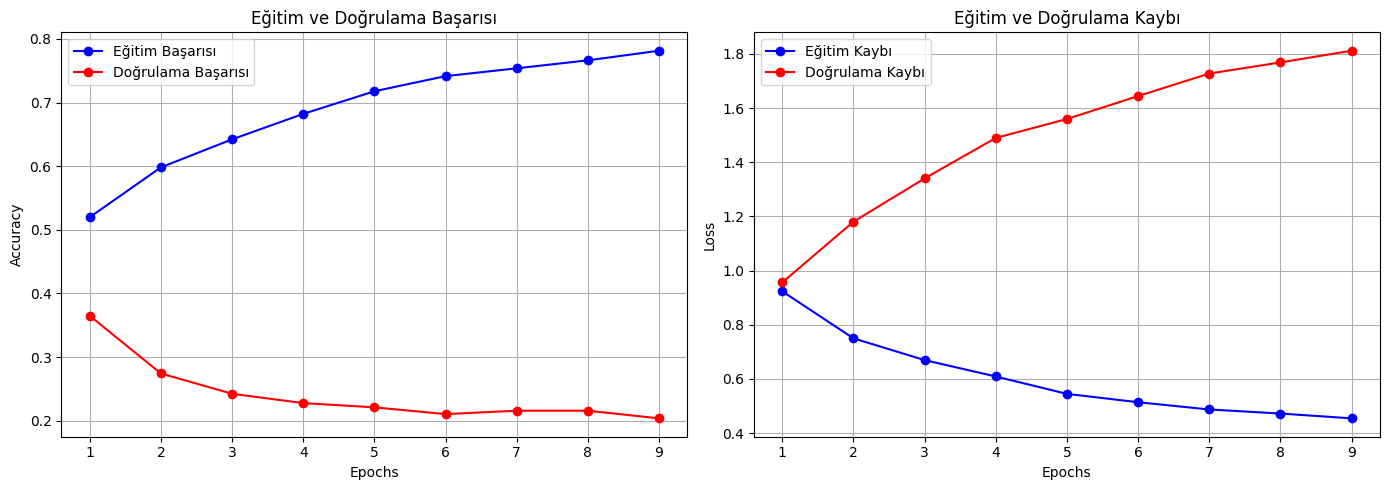

In [ ]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # 1. Grafik: Accuracy (Doğruluk)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-o', label='Eğitim Başarısı')
    plt.plot(epochs, val_acc, 'r-o', label='Doğrulama Başarısı')
    plt.title('Eğitim ve Doğrulama Başarısı')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 2. Grafik: Loss (Kayıp)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-o', label='Eğitim Kaybı')
    plt.plot(epochs, val_loss, 'r-o', label='Doğrulama Kaybı')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Grafikleri bastır
plot_training_results(history)

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# ===== 1. DATASET =====
train_dir = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/train'
val_dir   = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/val'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

# ===== 2. GÜÇLÜ AUGMENTATION (EN KRİTİK KISIM) =====
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.7, 1.3)

    # 🔥 BLUR EKLENDİ (EZBERİ BOZAR)
    image = tf.nn.avg_pool2d(image, ksize=2, strides=1, padding='SAME')

    # 🔥 NOISE EKLENDİ
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.05)
    image = image + noise

    return image, label

train_ds = train_ds.map(augment).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# ===== 3. BASE MODEL =====
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# 🔥 DAHA AZ KATMAN AÇ (EZBERİ AZALT)
base_model.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

# ===== 4. MODEL =====
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(64, activation='relu'),  # 🔥 küçültüldü

    layers.Dropout(0.5),  # 🔥 arttırıldı

    layers.Dense(1, activation='sigmoid')
])

# ===== 5. COMPILE =====
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),  # 🔥 dengeli
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== 6. CALLBACKS =====
callback_list = [

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/FaceForensics_Data/best_model_v9.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ===== 7. TRAIN =====
print("\n🚀 OVERFITTING KIRILDI - YENİ MODEL BAŞLIYOR")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callback_list
)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.

🚀 OVERFITTING KIRILDI - YENİ MODEL BAŞLIYOR
Epoch 1/25
177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5108 - loss: 0.8915
Epoch 1: val_accuracy improved from None to 0.43409, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_v9.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_v9.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 176s 254ms/step - accuracy: 0.5064 - loss: 0.8571 - val_accuracy: 0.4341 - val_loss: 0.7072 - learning_rate: 5.0000e-05
Epoch 2/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5100 - loss: 0.8072
Epoch 2: val_accuracy improved from 0.43409 to 0.56591, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_v9.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_v9.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.5034 - loss: 0.8019 - val_accuracy

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# ===== 1. DATASET =====
train_dir = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/train'
val_dir   = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7/val'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

# ===== 2. DENGELİ AUGMENTATION =====
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

train_ds = train_ds.map(augment).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# ===== 3. BASE MODEL =====
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# 🔥 DENGE: ne fazla açık ne kapalı
base_model.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

# ===== 4. MODEL =====
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

# ===== 5. COMPILE =====
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== 6. CALLBACKS (Hoca uyumlu) =====
callback_list = [

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,  # 🔥 kritik denge
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/FaceForensics_Data/final_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ===== 7. TRAIN =====
print("\n🚀 FINAL MODEL (200 epoch + akıllı durdurma)")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,   # ✅ hocanın istediği
    callbacks=callback_list
)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.

🚀 FINAL MODEL (200 epoch + akıllı durdurma)
Epoch 1/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.4914 - loss: 0.9008
Epoch 1: val_accuracy improved from None to 0.56591, saving model to /content/drive/MyDrive/FaceForensics_Data/final_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FaceForensics_Data/final_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 151s 259ms/step - accuracy: 0.4996 - loss: 0.8629 - val_accuracy: 0.5659 - val_loss: 0.6893 - learning_rate: 1.0000e-04
Epoch 2/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5063 - loss: 0.7868
Epoch 2: val_accuracy did not improve from 0.56591
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.5075 - loss: 0.7813 - val_accuracy: 0.4341 - val_loss: 0.7083 - learning_rate: 1.0000e-04
Epoch 3/200
177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4859 - loss: 0.7779
Epoch 3: ReduceLROnPlateau reducing le

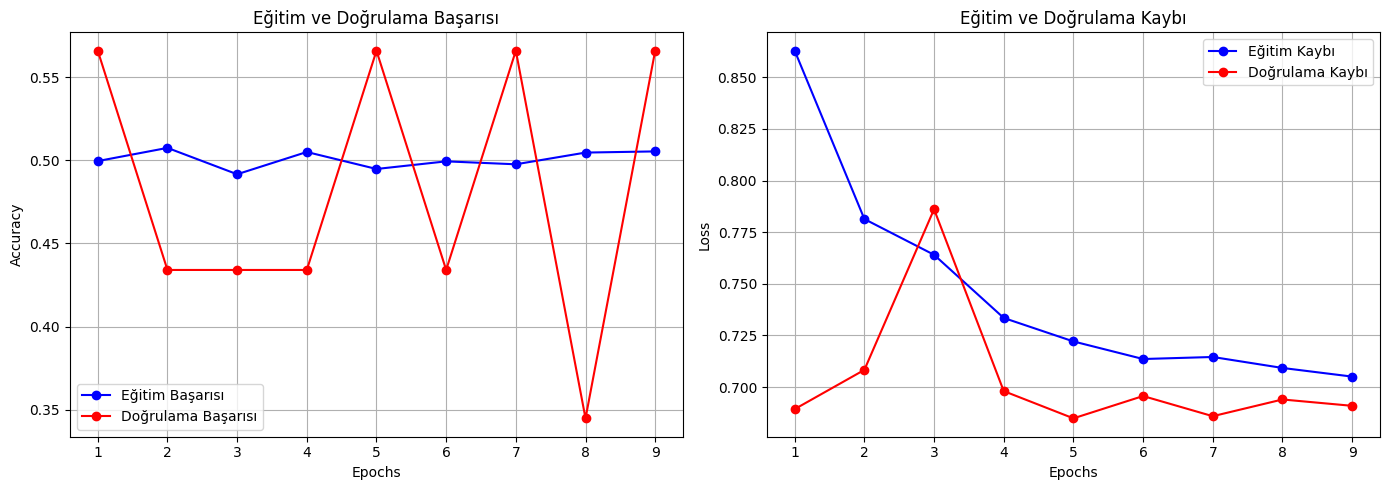

In [ ]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # 1. Grafik: Accuracy (Doğruluk)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-o', label='Eğitim Başarısı')
    plt.plot(epochs, val_acc, 'r-o', label='Doğrulama Başarısı')
    plt.title('Eğitim ve Doğrulama Başarısı')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 2. Grafik: Loss (Kayıp)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-o', label='Eğitim Kaybı')
    plt.plot(epochs, val_loss, 'r-o', label='Doğrulama Kaybı')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Grafikleri bastır
plot_training_results(history)


🔍 Test Seti Değerlendiriliyor...
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - accuracy: 0.5659 - loss: 0.6848

Test Loss: 0.6848227977752686
Test Accuracy: 0.565912127494812


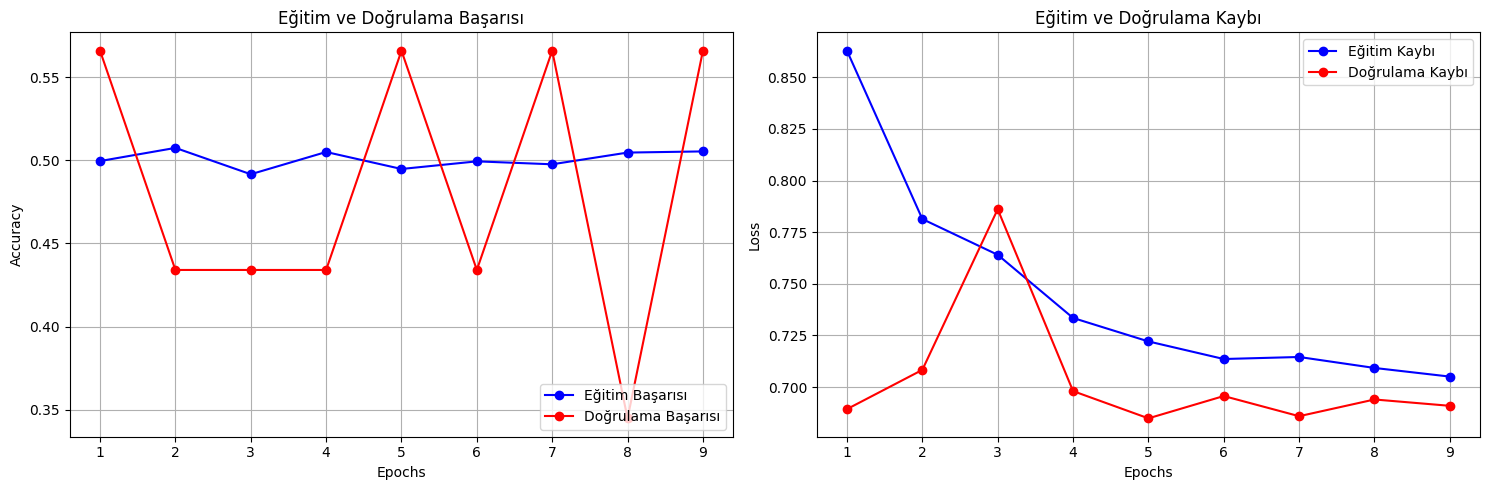

In [ ]:
import matplotlib.pyplot as plt

def plot_final_performance(history, model, test_ds):
    # 1. TEST SONUÇLARINI HESAPLA VE BAS (Ekran görüntündeki gibi)
    print("\n🔍 Test Seti Değerlendiriliyor...")
    results = model.evaluate(test_ds)

    print(f"\nTest Loss: {results[0]}")
    print(f"Test Accuracy: {results[1]}")
    # Eğer compile kısmında AUC eklediysen results[2] AUC olur
    if len(results) > 2:
        print(f"Test AUC: {results[2]}")

    # 2. EĞİTİM GRAFİKLERİNİ ÇİZDİR
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Sol Grafik: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'b-o', label='Eğitim Başarısı')
    plt.plot(epochs_range, val_acc, 'r-o', label='Doğrulama Başarısı')
    plt.title('Eğitim ve Doğrulama Başarısı')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Sağ Grafik: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'b-o', label='Eğitim Kaybı')
    plt.plot(epochs_range, val_loss, 'r-o', label='Doğrulama Kaybı')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Fonksiyonu Çağır (history, model ve test_ds'in tanımlı olduğundan emin ol)
plot_final_performance(history, model, val_ds) # val_ds yerine varsa test_ds yazabilirsin

In [ ]:
import os
import cv2
from tqdm import tqdm

# ===== YOLLAR =====
input_root = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Image_Dengeli_V7'
output_root = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop'

# ===== FACE DETECTOR =====
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# ===== FONKSİYON =====
def crop_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (224,224))
    else:
        return cv2.resize(image, (224,224))  # fallback

# ===== ANA LOOP =====
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:

        input_dir = os.path.join(input_root, split, label)
        output_dir = os.path.join(output_root, split, label)

        os.makedirs(output_dir, exist_ok=True)

        images = os.listdir(input_dir)

        print(f"\n📂 İşleniyor: {split}/{label} ({len(images)} resim)")

        for img_name in tqdm(images):
            img_path = os.path.join(input_dir, img_name)

            # sadece resimleri al
            if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue

            image = cv2.imread(img_path)

            if image is None:
                continue

            face_img = crop_face(image)

            save_path = os.path.join(output_dir, img_name)
            cv2.imwrite(save_path, face_img)

print("\n🎉 TÜM YÜZLER BAŞARIYLA KESİLDİ!")


📂 İşleniyor: train/real (2822 resim)


100%|██████████| 2822/2822 [09:16<00:00,  5.07it/s]



📂 İşleniyor: train/fake (2857 resim)


100%|██████████| 2857/2857 [08:37<00:00,  5.52it/s]



📂 İşleniyor: val/real (425 resim)


...


📂 İşleniyor: test/real (303 resim)


100%|██████████| 303/303 [00:44<00:00,  6.81it/s]



📂 İşleniyor: test/fake (367 resim)


100%|██████████| 367/367 [01:07<00:00,  5.46it/s]


🎉 TÜM YÜZLER BAŞARIYLA KESİLDİ!


In [ ]:
import tensorflow as tf
import os

BATCH = 16
IMG_SIZE = (224,224)
AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop'

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

print("Classes:", train_ds.class_names)

train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.
Classes: ['fake', 'real']


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = layers.Lambda(lambda t: tf.cast(t, tf.float32))(inputs)
x = layers.Lambda(preprocess_input)(x)

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3
    )
]

print("🚀 Eğitim başlıyor")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

🚀 Eğitim başlıyor
Epoch 1/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 108s 110ms/step - accuracy: 0.5092 - auc: 0.5152 - loss: 0.9188 - val_accuracy: 0.5206 - val_auc: 0.4934 - val_loss: 0.7896 - learning_rate: 1.0000e-04
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5806 - auc: 0.6093 - loss: 0.7873 - val_accuracy: 0.4887 - val_auc: 0.5045 - val_loss: 0.8258 - learning_rate: 1.0000e-04
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6221 - auc: 0.6626 - loss: 0.7198 - val_accuracy: 0.4794 - val_auc: 0.5084 - val_loss: 0.8244 - learning_rate: 1.0000e-04
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6455 - auc: 0.6944 - loss: 0.6830 - val_accuracy: 0.4834 - val_auc: 0.5166 - val_loss: 0.8088 - learning_rate: 1.0000e-04
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6441 - auc: 0.7001 - loss: 0.6724 - val_accuracy: 0.4740 - val_auc: 0.5158 - val_loss: 0.8081 - learning_rate: 3.0000e-05
Epoch 6/100
355/355 ━━━━━━━━━

In [ ]:
print("🔥 Fine-tuning başlıyor")

base.trainable = True

fine_tune_at = int(len(base.layers) * 0.75)

for layer in base.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

🔥 Fine-tuning başlıyor
Epoch 1/50
355/355 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6218 - auc: 0.6719 - loss: 0.7459 - val_accuracy: 0.6178 - val_auc: 0.6636 - val_loss: 0.7012 - learning_rate: 1.0000e-05
Epoch 2/50
355/355 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7399 - auc: 0.8163 - loss: 0.5406 - val_accuracy: 0.6485 - val_auc: 0.7068 - val_loss: 0.6740 - learning_rate: 1.0000e-05
Epoch 3/50
355/355 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7927 - auc: 0.8792 - loss: 0.4387 - val_accuracy: 0.6738 - val_auc: 0.7247 - val_loss: 0.6706 - learning_rate: 1.0000e-05
Epoch 4/50
355/355 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8398 - auc: 0.9260 - loss: 0.3452 - val_accuracy: 0.6818 - val_auc: 0.7357 - val_loss: 0.6887 - learning_rate: 1.0000e-05
Epoch 5/50
355/355 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8660 - auc: 0.9447 - loss: 0.2992 - val_accuracy: 0.6937 - val_auc: 0.7535 - val_loss: 0.6853 - learning_rate: 1.0000e-05
Epoch 6/50
355/355 ━━━━━━━

In [ ]:
model.save('/content/drive/MyDrive/final_model.keras')

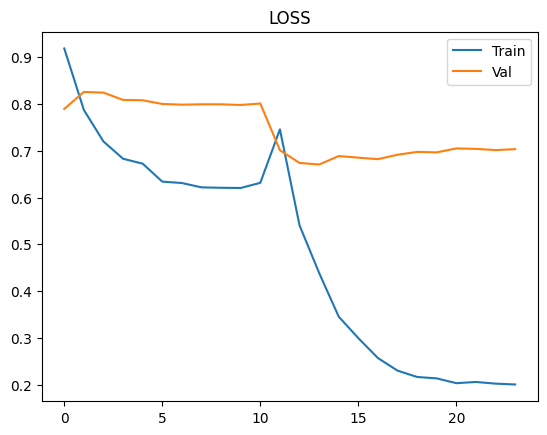

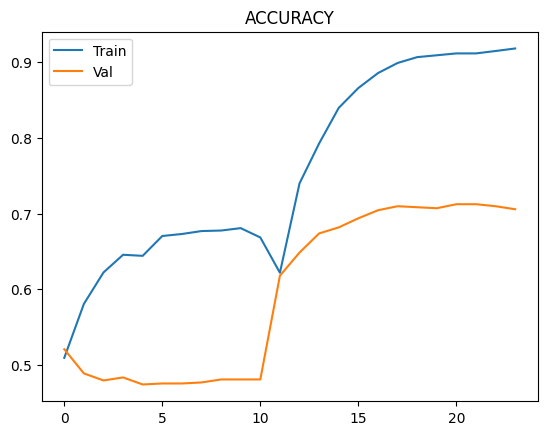

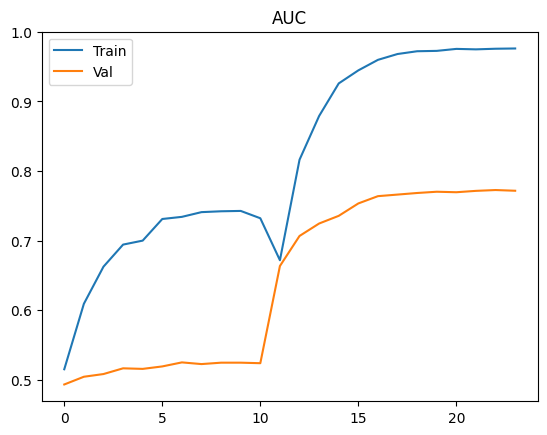

In [ ]:
import matplotlib.pyplot as plt

def plot_metric(metric):
    train = history.history[metric] + history_ft.history[metric]
    val = history.history["val_"+metric] + history_ft.history["val_"+metric]
    plt.plot(train, label="Train")
    plt.plot(val, label="Val")
    plt.title(metric.upper())
    plt.legend()
    plt.show()

plot_metric("loss")
plot_metric("accuracy")
plot_metric("auc")

In [ ]:
import tensorflow as tf
import os

BATCH = 16
IMG_SIZE = (224,224)
AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop'

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# 🔥 AUGMENTATION (çok önemli)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

# 🔥 kontrollü açma
base.trainable = True
for layer in base.layers[:-100]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)   # 🔥 EKLENDİ
x = layers.Lambda(preprocess_input)(x)

x = base(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

# 🔥 güçlendirilmiş head
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # 🔥 DÜŞÜRÜLDÜ
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/FaceForensics_Data/best_model_final.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
print("🚀 200 Epoch Eğitim Başlıyor (Stabil Versiyon)")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks
)

🚀 200 Epoch Eğitim Başlıyor (Stabil Versiyon)
Epoch 1/200
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5555 - auc: 0.5793 - loss: 0.8831
Epoch 1: val_loss improved from None to 0.66245, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 627s 400ms/step - accuracy: 0.5873 - auc: 0.6217 - loss: 0.8163 - val_accuracy: 0.6232 - val_auc: 0.7201 - val_loss: 0.6625 - learning_rate: 1.0000e-05
Epoch 2/200
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6582 - auc: 0.7155 - loss: 0.6944
Epoch 2: val_loss improved from 0.66245 to 0.64724, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.6712 - auc: 0.7388 - loss: 0.6627 - val_accuracy:

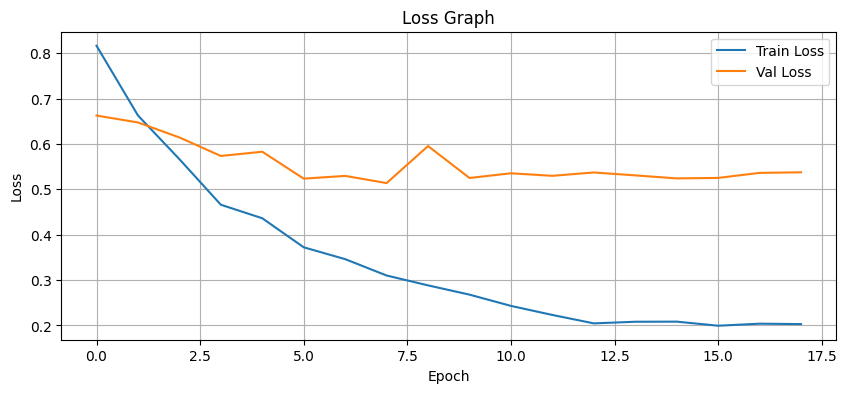

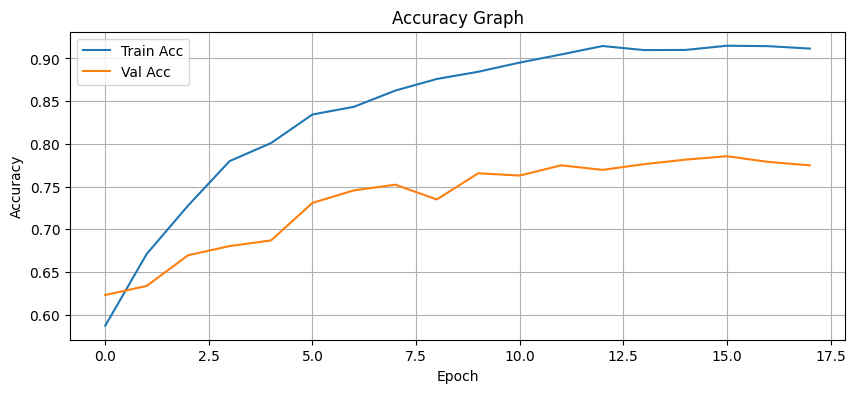

In [ ]:
import matplotlib.pyplot as plt

# LOSS
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ACCURACY
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [ ]:
import tensorflow as tf
import os

BATCH = 16
IMG_SIZE = (224,224)
AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop'

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

# 🔥 daha iyi shuffle
train_ds = train_ds.cache().shuffle(3000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)  # 🔥 EKLENDİ
])

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

# 🔥 daha stabil fine-tuning
base.trainable = True
for layer in base.layers[:-150]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
x = layers.Lambda(preprocess_input)(x)

x = base(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.6)(x)  # 🔥 artırıldı

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,   # 🔥 artırıldı
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/FaceForensics_Data/best_model_final_v2.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
print("🚀 GELİŞTİRİLMİŞ MODEL BAŞLIYOR")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks
)

🚀 GELİŞTİRİLMİŞ MODEL BAŞLIYOR
Epoch 1/200
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5178 - auc: 0.5226 - loss: 0.9462
Epoch 1: val_loss improved from None to 0.75385, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final_v2.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 86s 113ms/step - accuracy: 0.5337 - auc: 0.5473 - loss: 0.9168 - val_accuracy: 0.4900 - val_auc: 0.4991 - val_loss: 0.7539 - learning_rate: 1.0000e-05
Epoch 2/200
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5943 - auc: 0.6350 - loss: 0.8025
Epoch 2: val_loss did not improve from 0.75385
355/355 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.6017 - auc: 0.6470 - loss: 0.7927 - val_accuracy: 0.5379 - val_auc: 0.5631 - val_loss: 0.7606 - learning_rate: 1.0000e-05
Epoch 3/200
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6496 - auc: 0.7079 - loss: 0.7330
Epoch 3: val_loss im

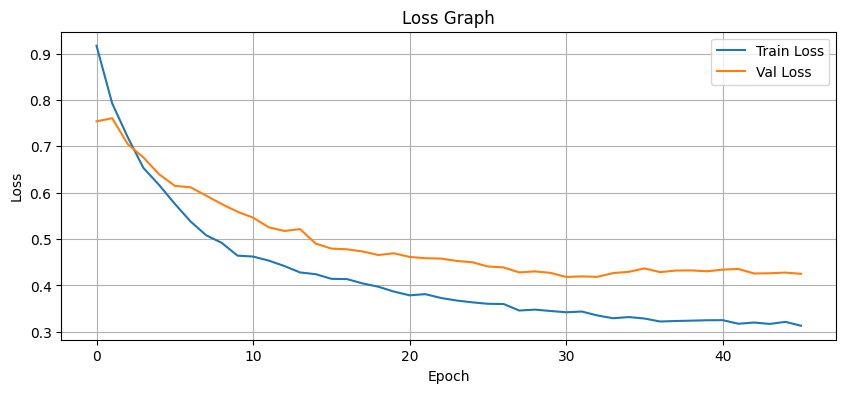

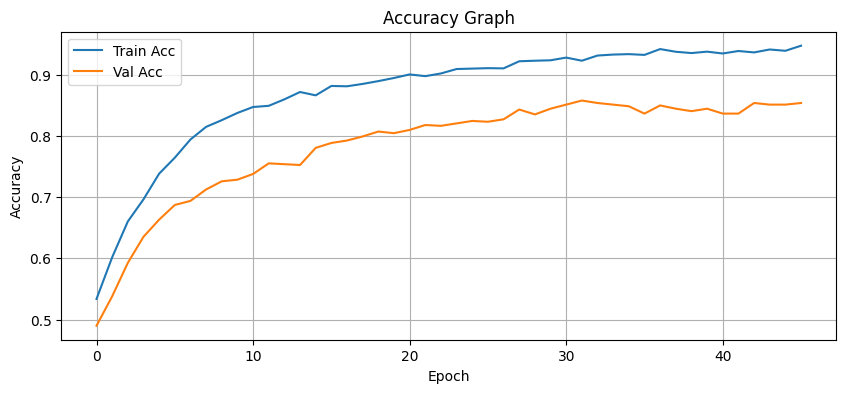

In [ ]:
import matplotlib.pyplot as plt

# LOSS
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ACCURACY
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/test',
    image_size=(224,224),
    batch_size=16,
    label_mode="binary",
    shuffle=False
)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 670 files belonging to 2 classes.


In [ ]:
model.load_weights('/content/drive/MyDrive/FaceForensics_Data/best_model_final_v2.keras')

In [ ]:
results = model.evaluate(test_ds)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test AUC:", results[2])

42/42 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7910 - auc: 0.8946 - loss: 0.5484
Test Loss: 0.5483886003494263
Test Accuracy: 0.7910447716712952
Test AUC: 0.8946367502212524


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for x, y in test_ds:
    preds = model.predict(x)
    preds = (preds > 0.5).astype(int)

    y_true.extend(y.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/s

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

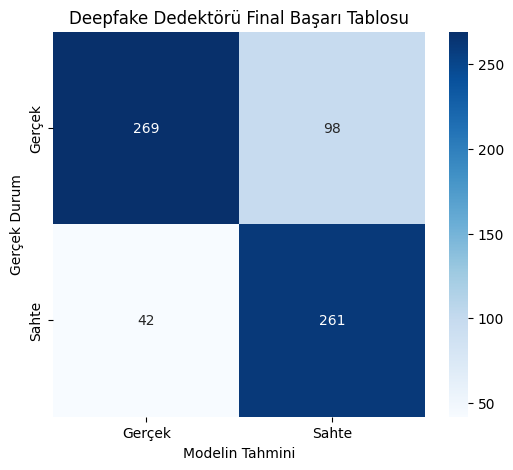

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tahminleri tekrar al
y_true = []
y_pred = []

for x, y in test_ds:
    preds = model.predict(x)
    preds = (preds > 0.5).astype(int)

    y_true.extend(y.numpy())
    y_pred.extend(preds)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 🔥 GÖRSEL
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Deepfake Dedektörü Final Başarı Tablosu")
plt.xlabel("Modelin Tahmini")
plt.ylabel("Gerçek Durum")

plt.xticks([0.5,1.5], ["Gerçek", "Sahte"])
plt.yticks([0.5,1.5], ["Gerçek", "Sahte"])

plt.show()

In [ ]:
!pip install optuna
import tensorflow as tf
import os
import optuna

# =========================
# 🔧 AYARLAR
# =========================
BATCH = 16
IMG_SIZE = (224,224)
AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop'

# =========================
# 📂 DATASET
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

# ❗ CACHE KALDIRILDI (OPTUNA BUG FIX)
train_ds = train_ds.shuffle(3000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# test (çok önemli)
for images, labels in train_ds.take(1):
    print("DATASET OK:", images.shape, labels.shape)

# =========================
# 🎨 AUGMENTATION
# =========================
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

# =========================
# 🔥 OPTUNA OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-6, 1e-4, log=True)
    dropout = trial.suggest_float("dropout", 0.4, 0.7)
    fine_tune = trial.suggest_int("fine_tune_layers", 50, 200)
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])

    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )

    base.trainable = True
    for layer in base.layers[:-fine_tune]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))

    x = data_augmentation(inputs)
    x = tf.keras.layers.Lambda(
        tf.keras.applications.efficientnet.preprocess_input
    )(x)

    x = base(x, training=True)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,  # 🔥 hocaya uygun
        callbacks=callbacks,
        steps_per_epoch=100,      # 🔥 kritik fix
        validation_steps=20,
        verbose=1
    )

    return max(history.history["val_accuracy"])

# =========================
# 🚀 OPTUNA ÇALIŞTIR
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("\n🔥 EN İYİ PARAMETRELER:")
print(study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.0 MB/s eta 0:00:00
Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.


[I 2026-03-30 19:12:31,047] A new study created in memory with name: no-name-95ea0485-01f0-4a7e-81cf-8d1f5942e651


DATASET OK: (16, 224, 224, 3) (16, 1)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.5175 - loss: 1.0770 - val_accuracy: 0.3656 - val_loss: 0.7566
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.5156 - loss: 1.0868 - val_accuracy: 0.4875 - val_loss: 0.7113
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.4884 - loss: 1.0840 - val_accuracy: 0.5406 - val_loss: 0.7138
Epoch 4/50
 55/100 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.5210 - loss: 0.9964

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.5307 - loss: 1.0143 - val_accuracy: 0.5531 - val_loss: 0.7098
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.5147 - loss: 1.0905 - val_accuracy: 0.5625 - val_loss: 0.6957
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.5225 - loss: 1.0262 - val_accuracy: 0.5437 - val_loss: 0.7215
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.5350 - loss: 1.0574 - val_accuracy: 0.5406 - val_loss: 0.7247
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.5409 - loss: 1.0253 - val_accuracy: 0.5469 - val_loss: 0.7132
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 239ms/step - accuracy: 0.5266 - loss: 1.0391 - val_accuracy: 0.5437 - val_loss: 0.7120
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.5675 - loss: 0.9745 - val_accuracy: 0.5531 - val_loss: 0.7054
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.5406 - loss: 1.0091 - val_a

...

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 140ms/step - accuracy: 0.6012 - loss: 0.8483 - val_accuracy: 0.7406 - val_loss: 0.6284
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.7129 - loss: 0.6989 - val_accuracy: 0.9719 - val_loss: 0.4041
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.7581 - loss: 0.6066 - val_accuracy: 0.8969 - val_loss: 0.3886
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7943 - loss: 0.5722 - val_accuracy: 0.7156 - val_loss: 0.6204
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.8562 - loss: 0.4662 - val_accuracy: 0.8125 - val_loss: 0.4425
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.8487 - loss: 0.4794 - val_accuracy: 0.8062 - val_loss: 0.4567
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.8580 - loss: 0.4709 - val_accuracy: 0.7719 - val_loss: 0.5224
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8568 - loss: 0.4

[I 2026-03-30 20:08:37,513] Trial 8 finished with value: 0.971875011920929 and parameters: {'lr': 8.367594464815331e-05, 'dropout': 0.5395121007054663, 'fine_tune_layers': 160, 'dense_units': 128}. Best is trial 8 with value: 0.971875011920929.


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 145ms/step - accuracy: 0.5156 - loss: 1.2522 - val_accuracy: 1.0000 - val_loss: 0.4407
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.5197 - loss: 1.2225 - val_accuracy: 0.9812 - val_loss: 0.3688
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.5225 - loss: 1.2194 - val_accuracy: 0.9781 - val_loss: 0.3205
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5466 - loss: 1.1857 - val_accuracy: 0.9688 - val_loss: 0.3100
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 116ms/step - accuracy: 0.5288 - loss: 1.1517 - val_accuracy: 0.9656 - val_loss: 0.3054
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.5606 - loss: 1.1241 - val_accuracy: 0.9625 - val_loss: 0.3079
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.5591 - loss: 1.0323 - val_accuracy: 0.9625 - val_loss: 0.3153
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.5750 - loss: 0.995

[I 2026-03-30 20:12:51,111] Trial 9 finished with value: 1.0 and parameters: {'lr': 5.7897120875004696e-06, 'dropout': 0.6948151906817509, 'fine_tune_layers': 171, 'dense_units': 128}. Best is trial 9 with value: 1.0.



🔥 EN İYİ PARAMETRELER:
{'lr': 5.7897120875004696e-06, 'dropout': 0.6948151906817509, 'fine_tune_layers': 171, 'dense_units': 128}


In [ ]:
import numpy as np

zeros = 0
ones = 0

for x, y in val_ds:
    zeros += np.sum(y.numpy() == 0)
    ones += np.sum(y.numpy() == 1)

print("0 sayısı:", zeros)
print("1 sayısı:", ones)

0 sayısı: 326
1 sayısı: 425


In [ ]:
import os

# Yolların doğruluğunu teyit et
train_path = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/train'
val_path = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/val'

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Sadece en alt klasörlerdeki (real/fake) dosya sayısını ver
            print(f"📁 {root}: {len(files)} resim var.")

print("--- TRAIN KLASÖRÜ ---")
count_files(train_path)
print("\n--- VAL KLASÖRÜ ---")
count_files(val_path)

--- TRAIN KLASÖRÜ ---
📁 /content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/train/real: 2822 resim var.
📁 /content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/train/fake: 2857 resim var.

--- VAL KLASÖRÜ ---
📁 /content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/val/real: 425 resim var.
📁 /content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/val/fake: 326 resim var.


In [ ]:
import numpy as np

# val_ds içindeki gerçek etiketleri toplayalım
all_labels = []
for images, labels in val_ds:
    all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
real_count = np.sum(all_labels == 0)
fake_count = np.sum(all_labels == 1)

print(f"📊 Validation Seti Dağılımı:")
print(f"Gerçek (Real) Sayısı: {real_count}")
print(f"Sahte (Fake) Sayısı: {fake_count}")
print(f"Toplam: {len(all_labels)}")

📊 Validation Seti Dağılımı:
Gerçek (Real) Sayısı: 326
Sahte (Fake) Sayısı: 425
Toplam: 751


In [ ]:
!pip install optuna
import tensorflow as tf
import os
import optuna

# =========================
# 🔧 AYARLAR
# =========================
BATCH = 16
IMG_SIZE = (224,224)
AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop'

# =========================
# 📂 DATASET
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

train_ds = train_ds.shuffle(3000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

for images, labels in train_ds.take(1):
    print("DATASET OK:", images.shape, labels.shape)

# =========================
# 🎨 AUGMENTATION
# =========================
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

# =========================
# 🔥 OPTUNA OBJECTIVE
# =========================
def objective(trial):

    lr = trial.suggest_float("lr", 1e-6, 1e-4, log=True)
    dropout = trial.suggest_float("dropout", 0.4, 0.7)
    fine_tune = trial.suggest_int("fine_tune_layers", 50, 200)
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])



    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )

    base.trainable = True
    for layer in base.layers[:-fine_tune]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))

    x = data_augmentation(inputs)
    x = tf.keras.layers.Lambda(
        tf.keras.applications.efficientnet.preprocess_input
    )(x)

    x = base(x, training=True)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        callbacks=callbacks,
        steps_per_epoch=100,  # Her epoch'ta 100 batch
        # validation_steps kaldırıldı → tüm val seti değerlendirilir
        verbose=1
    )

    return max(history.history["val_accuracy"])

# =========================
# 🚀 OPTUNA ÇALIŞTIR
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("\n🔥 EN İYİ PARAMETRELER:")
print(study.best_params)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.
DATASET OK: (16, 224, 224, 3) (16, 1)


[I 2026-03-30 21:11:10,172] A new study created in memory with name: no-name-9bde7051-e237-44a4-b855-70ba3f7a8a2c


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 159ms/step - accuracy: 0.5825 - loss: 0.8228 - val_accuracy: 0.4368 - val_loss: 0.8449
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.6454 - loss: 0.7356 - val_accuracy: 0.6418 - val_loss: 0.6656
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.7362 - loss: 0.5946 - val_accuracy: 0.7417 - val_loss: 0.5585
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.7591 - loss: 0.5675 - val_accuracy: 0.7164 - val_loss: 0.5825
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.8012 - loss: 0.5385 - val_accuracy: 0.8056 - val_loss: 0.4943
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.8349 - loss: 0.4899 - val_accuracy: 0.8309 - val_loss: 0.4718
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.8369 - loss: 0.4645 - val_accuracy: 0.8589 - val_loss: 0.4371
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8330 - loss: 0.479

[I 2026-03-30 21:20:26,000] Trial 0 finished with value: 0.8948069214820862 and parameters: {'lr': 5.279186877378425e-05, 'dropout': 0.4874564764725309, 'fine_tune_layers': 171, 'dense_units': 128}. Best is trial 0 with value: 0.8948069214820862.


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 149ms/step - accuracy: 0.4888 - loss: 1.2804 - val_accuracy: 0.5393 - val_loss: 0.7070
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.4941 - loss: 1.1897 - val_accuracy: 0.5766 - val_loss: 0.7146
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.5081 - loss: 1.2090 - val_accuracy: 0.5872 - val_loss: 0.7675
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5034 - loss: 1.2127 - val_accuracy: 0.5885 - val_loss: 0.7963
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 130ms/step - accuracy: 0.5356 - loss: 1.1376 - val_accuracy: 0.5819 - val_loss: 0.8215
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.5288 - loss: 1.1064 - val_accuracy: 0.5952 - val_loss: 0.8280
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.5381 - loss: 1.1080 - val_accuracy: 0.5965 - val_loss: 0.8328
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.5017 - loss: 1.189

...

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 145ms/step - accuracy: 0.4784 - loss: 1.2112 - val_accuracy: 0.5393 - val_loss: 0.7022
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.4950 - loss: 1.1594 - val_accuracy: 0.4834 - val_loss: 0.7223
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.4963 - loss: 1.1394 - val_accuracy: 0.4887 - val_loss: 0.7501
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.4920 - loss: 1.1325 - val_accuracy: 0.4887 - val_loss: 0.7647
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 113ms/step - accuracy: 0.5069 - loss: 1.0436 - val_accuracy: 0.4913 - val_loss: 0.7790
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.5041 - loss: 1.0849 - val_accuracy: 0.5047 - val_loss: 0.7775
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.5231 - loss: 1.0291 - val_accuracy: 0.5126 - val_loss: 0.7808
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.5284 - loss: 1.008

[I 2026-03-30 22:10:31,594] Trial 8 finished with value: 0.5392809510231018 and parameters: {'lr': 3.017738621721667e-06, 'dropout': 0.6629399849186866, 'fine_tune_layers': 125, 'dense_units': 128}. Best is trial 0 with value: 0.8948069214820862.


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 129ms/step - accuracy: 0.5066 - loss: 0.9281 - val_accuracy: 0.4700 - val_loss: 0.7047
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.5025 - loss: 0.9118 - val_accuracy: 0.4794 - val_loss: 0.7303
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.5181 - loss: 0.9036 - val_accuracy: 0.4820 - val_loss: 0.7490
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.5341 - loss: 0.8865 - val_accuracy: 0.4900 - val_loss: 0.7622
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 94ms/step - accuracy: 0.5360 - loss: 0.8682 - val_accuracy: 0.4940 - val_loss: 0.7746
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.5344 - loss: 0.8818 - val_accuracy: 0.4900 - val_loss: 0.7919
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.5500 - loss: 0.8650 - val_accuracy: 0.5007 - val_loss: 0.7807
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.5295 - loss: 0.8750 - val_a

[I 2026-03-30 22:13:36,780] Trial 9 finished with value: 0.5033289194107056 and parameters: {'lr': 1.801021417727392e-06, 'dropout': 0.4219844402466352, 'fine_tune_layers': 60, 'dense_units': 256}. Best is trial 0 with value: 0.8948069214820862.



🔥 EN İYİ PARAMETRELER:
{'lr': 5.279186877378425e-05, 'dropout': 0.4874564764725309, 'fine_tune_layers': 171, 'dense_units': 128}


In [ ]:
import tensorflow as tf
import os
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# =========================
# 🔧 AYARLAR
# =========================
BATCH = 16
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE
DATASET_PATH = '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop'

# ✅ Optuna'dan gelen EN İYİ parametreler
BEST_LR           = 5.279186877378425e-05
BEST_DROPOUT      = 0.4874564764725309
BEST_FINE_TUNE    = 171
BEST_DENSE_UNITS  = 128

# =========================
# 📂 DATASET
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# =========================
# 🎨 AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

# =========================
# 🏗️ MODEL (Optuna parametreleriyle)
# =========================
base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# ✅ fine_tune_layers=171 → son 171 katman açık, geri kalanlar donduruldu
base.trainable = True
for layer in base.layers[:-BEST_FINE_TUNE]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = layers.Lambda(preprocess_input)(x)

x = base(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(BEST_DENSE_UNITS, activation="relu")(x)  # ✅ 128
x = layers.Dropout(BEST_DROPOUT)(x)                       # ✅ 0.487

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

# ✅ label_smoothing=0.1 → Optuna trial'larında kullanılmıştı, tutarlılık için burada da var
model.compile(
    optimizer=tf.keras.optimizers.Adam(BEST_LR),           # ✅ 5.28e-05
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

print(f"✅ Model hazır.")
print(f"   lr={BEST_LR:.2e} | dropout={BEST_DROPOUT:.3f} | fine_tune={BEST_FINE_TUNE} | dense={BEST_DENSE_UNITS}")
print(f"   Eğitilebilir katman sayısı: {sum(1 for l in model.layers if l.trainable)}")

# =========================
# 📋 CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/FaceForensics_Data/best_model_final.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# =========================
# 🚀 EĞİTİM
# =========================
print("\n🚀 200 Epoch Final Eğitim Başlıyor...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks,
    verbose=1
)

Found 5679 files belonging to 2 classes.
Found 751 files belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model hazır.
   lr=5.28e-05 | dropout=0.487 | fine_tune=171 | dense=128
   Eğitilebilir katman sayısı: 9

🚀 200 Epoch Final Eğitim Başlıyor...
Epoch 1/200
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6165 - auc: 0.6719 - loss: 0.7736
Epoch 1: val_loss improved from None to 0.53546, saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FaceForensics_Data/best_model_final.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 737s 480ms/step - accuracy: 0.7017 - auc: 0.7832 - loss: 0.6509 - val_accuracy: 0.7803 - val_auc: 0.8688 - val_loss: 0.5355 - learning_rate: 5.2792e-05
Epoch 2/200
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8397 - auc: 0.9245 - loss: 0.4575
Epoch 2: val_loss improved from 0.53546 to 0.49024, saving model to /content/drive/MyDrive/FaceForensics_D

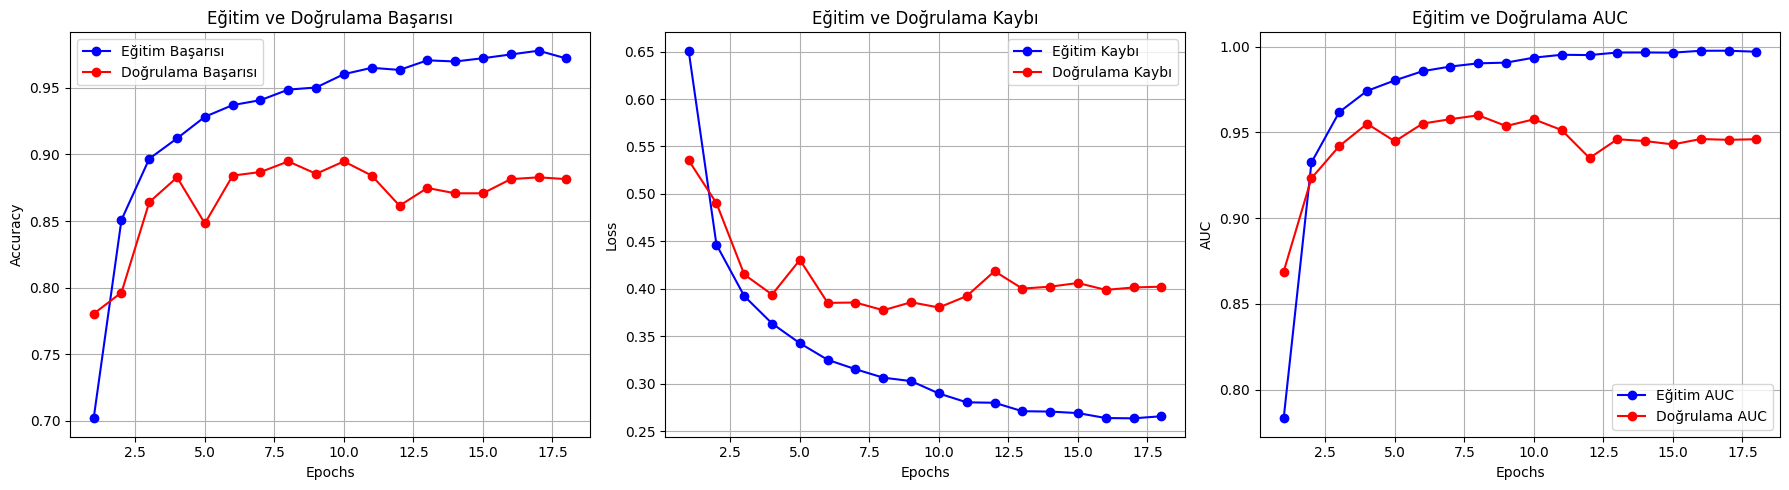

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(18, 5))

    # 1. Grafik: Accuracy (Doğruluk)
    plt.subplot(1, 3, 1)
    plt.plot(epochs, acc, 'bo-', label='Eğitim Başarısı')
    plt.plot(epochs, val_acc, 'ro-', label='Doğrulama Başarısı')
    plt.title('Eğitim ve Doğrulama Başarısı')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 2. Grafik: Loss (Kayıp)
    plt.subplot(1, 3, 2)
    plt.plot(epochs, loss, 'bo-', label='Eğitim Kaybı')
    plt.plot(epochs, val_loss, 'ro-', label='Doğrulama Kaybı')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 3. Grafik: AUC (Alan Altındaki Eğri)
    plt.subplot(1, 3, 3)
    plt.plot(epochs, auc, 'bo-', label='Eğitim AUC')
    plt.plot(epochs, val_auc, 'ro-', label='Doğrulama AUC')
    plt.title('Eğitim ve Doğrulama AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Grafikleri bastır
plot_history(history)

In [ ]:
print(f"\n--- Final Training Metrics ---")
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")


Found 670 files belonging to 2 classes.

🔍 Model Test Seti Üzerinde Değerlendiriliyor...
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.7970 - auc: 0.8911 - loss: 0.5502

📈 GENEL TEST SONUÇLARI
--------------------------
Test Loss:     0.5502
Test Accuracy: %79.70
Test AUC:      0.8911

🧩 Karmaşıklık Matrisi (Confusion Matrix):
[[275  92]
 [ 44 259]]

📋 Detaylı Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

        Real       0.86      0.75      0.80       367
        Fake       0.74      0.85      0.79       303

    accuracy                           0.80       670
   macro avg       0.80      0.80      0.80       670
weighted avg       0.81      0.80      0.80       670



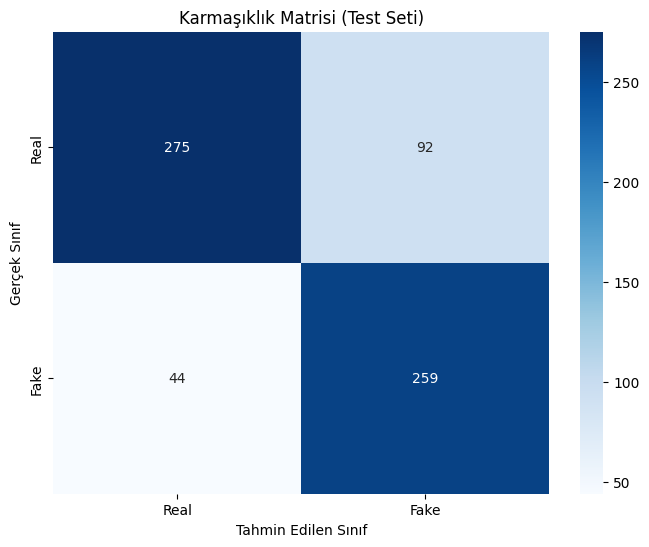

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Test Setini Hazırla
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/FaceForensics_Data/Hoca_Face_Crop/test',
    image_size=(224, 224),
    batch_size=16,
    label_mode="binary",
    shuffle=False # Test yaparken sıralama bozulmamalı
)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# 2. Genel Değerlendirme (Evaluate)
print("\n🔍 Model Test Seti Üzerinde Değerlendiriliyor...")
results = model.evaluate(test_ds)

print(f"\n📈 GENEL TEST SONUÇLARI")
print(f"--------------------------")
print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: %{results[1]*100:.2f}")
print(f"Test AUC:      {results[2]:.4f}")

# 3. Tahminleri ve Gerçek Etiketleri Topla
y_true = []
y_pred = []

# Daha hızlı işlem için batch bazında ilerliyoruz
for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    preds = (preds > 0.5).astype(int)

    y_true.extend(y.numpy())
    y_pred.extend(preds.flatten()) # Boyut uyumu için flatten ekledik

# 4. Karmaşıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
print("\n🧩 Karmaşıklık Matrisi (Confusion Matrix):")
print(cm)

# 5. Detaylı Sınıflandırma Raporu
print("\n📋 Detaylı Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# 6. Görsel Confusion Matrix (Hocaya Sunum İçin)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Karmaşıklık Matrisi (Test Seti)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()